In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import components.broadcast_components.WZ_models.wz_quant_ANN
import components.broadcast_components.WZ_models.wz_quant_RNN
import importlib

# --------------------------------
torch.set_float32_matmul_precision('medium')
import logging
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
import warnings
warnings.filterwarnings("ignore", message="Starting from v1.9.0, `tensorboardX` has been removed")
warnings.filterwarnings("ignore", message="You defined a `validation_step` but have no `val_dataloader`")
warnings.filterwarnings("ignore", message="Consider setting `persistent_workers=True` in 'train_dataloader'")
warnings.filterwarnings("ignore", message="The 'val_dataloader' does not have")

# --------------------------------

In [52]:
import gzip
import pickle
y=[]
for i in range(3):
    path_to_grad = f'exp_data/single_worker_sgd_resnet_raw_grads/corr_res_round_0,epoch_9,batch_{i}.pkl.gz'
    with gzip.open(path_to_grad, 'rb') as f:
        y += [pickle.load(f).numpy().astype(np.float32)]
y = np.sum(y, axis=0)
side_info_data = []

In [71]:
y = np.random.normal(0,1, 1_000_000,).astype(np.float32)
# side_info_data = y*0

side_info_data = []#[side_info_data]

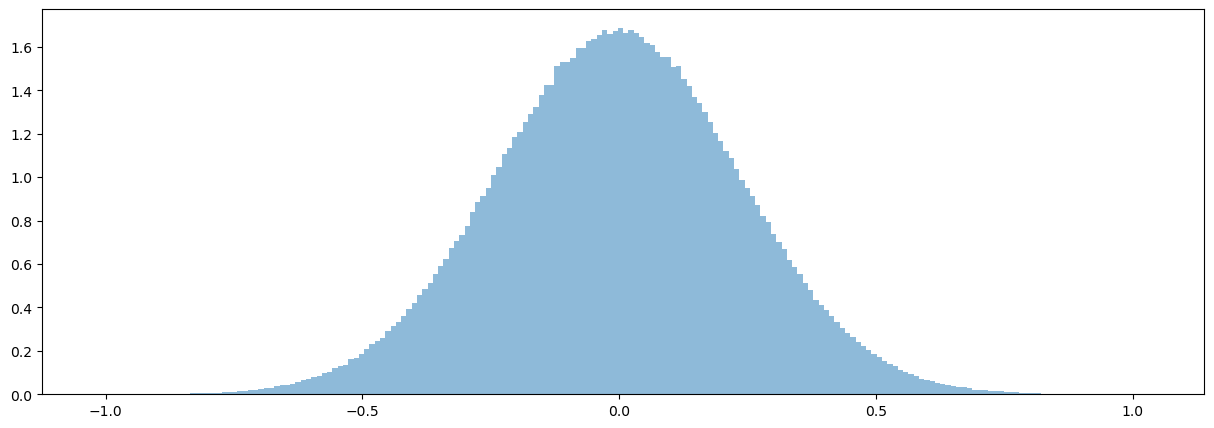

In [72]:
temp=np.percentile(y, [0.0003, 99.9997])
temp=((y>=temp[0]) * (y<=temp[1]))
y = y[temp]

temp=np.percentile(y, [0.001, 99.999])
y = ((y - temp[0]) / (temp[1]-temp[0]) *2 -1).astype(np.float32)

y_argsort = np.argsort(y)
side_info_data = [a[temp] for a in side_info_data]

plt.figure(figsize=(15, 5))
plt.hist(y, 200, density=True, alpha=0.5)
# plt.hist(side_info_data[0], 200, density=True, alpha=0.5)
# plt.ylim(0,5)
plt.show()

In [54]:
importlib.reload(components.broadcast_components.WZ_models.wz_quant_ANN)
importlib.reload(components.broadcast_components.WZ_models.wz_quant_RNN)
from components.broadcast_components.WZ_models.wz_quant_ANN import WZQuantizer
from components.broadcast_components.WZ_models.wz_quant_RNN import PL_EncoderDecoder_RNN

wz_model = PL_EncoderDecoder_RNN(inp_dim=1, side_info_size=0, num_planes=3, bins_per_plane=4, tau=5, reconst_ld=3.5, lr=8e-4, ).to(torch.float32)
wz_quantizer = WZQuantizer(wz_model, train_sample_size=200_000, count_side_info_data=0, enable_progress_bar=True)

wz_quantizer.train_model(y, side_info_data, epoch=20, batch_size=1_000)

deunified_bins_list = wz_quantizer.encoding_process(y)
bins = wz_quantizer.wz_pl_model.unify_bins(deunified_bins_list)
y_pred = wz_quantizer.decoding_process(bins, side_info_data, len(y))
print('mse ', np.mean(np.abs(y - y_pred)))
print(f'mape %: {np.sum(np.abs(y - y_pred)) / np.sum(np.abs(y)) * 100 :.2f}%')

          - training wz models


Training: |          | 0/? [00:00<?, ?it/s]

mse  0.006415059
mape %: 5.15%


In [4]:
# model_check_path = '../data/basicRNN_3plane_4bins_state.pt'
# model = wz_quantizer.wz_pl_model
# torch.save(model.state_dict(), model_check_path)
# model.load_state_dict(torch.load(model_check_path, map_location='cpu'))

In [5]:
# plt.figure(figsize=(17, 5))
# plt.plot(bins[y_argsort]/(wz_quantizer.bin_count-1))
# plt.plot(y_pred[y_argsort], label='predicted', linewidth=1)
# plt.plot(y[y_argsort], label='true', linewidth=1)

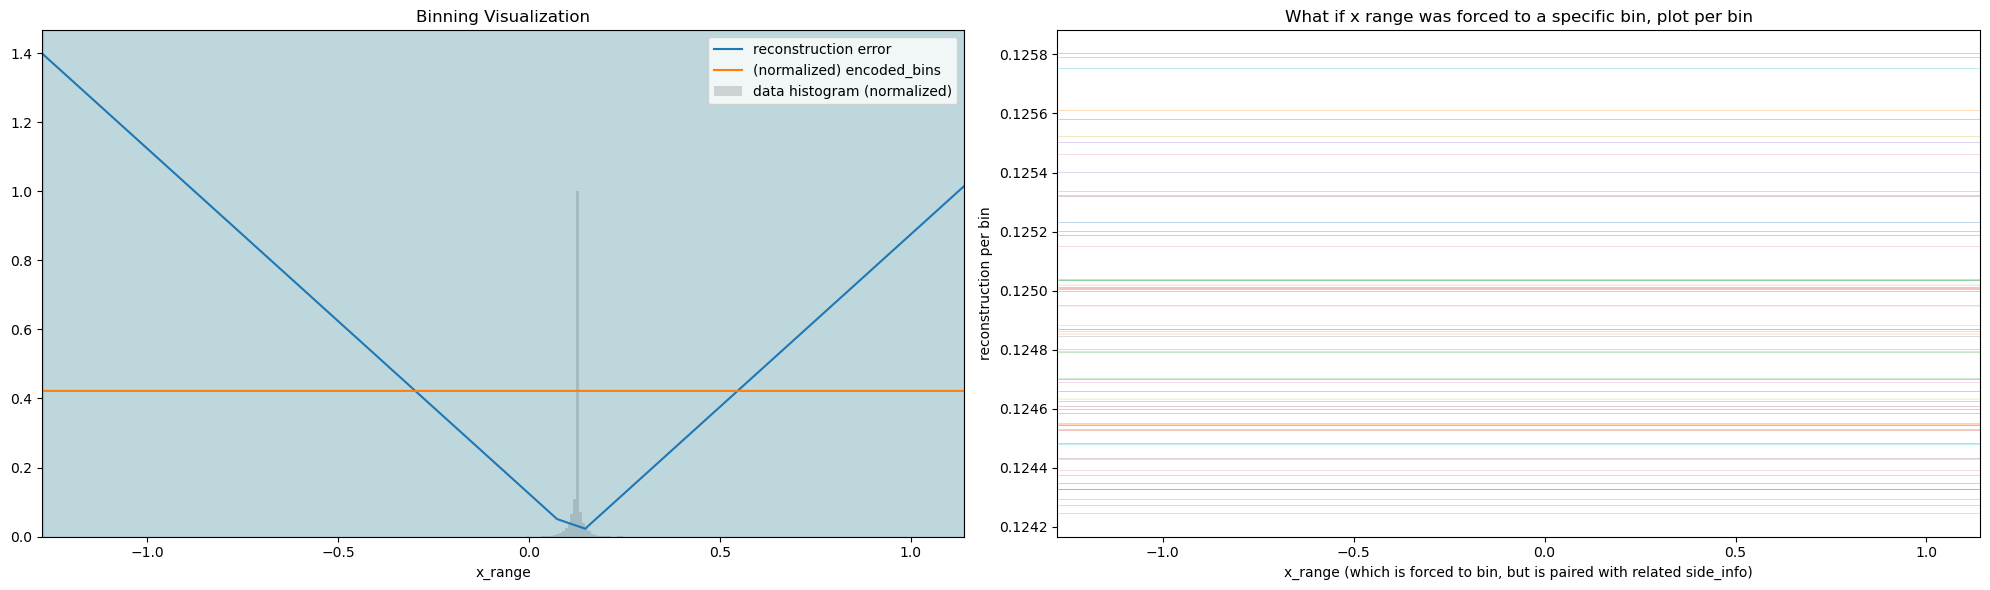

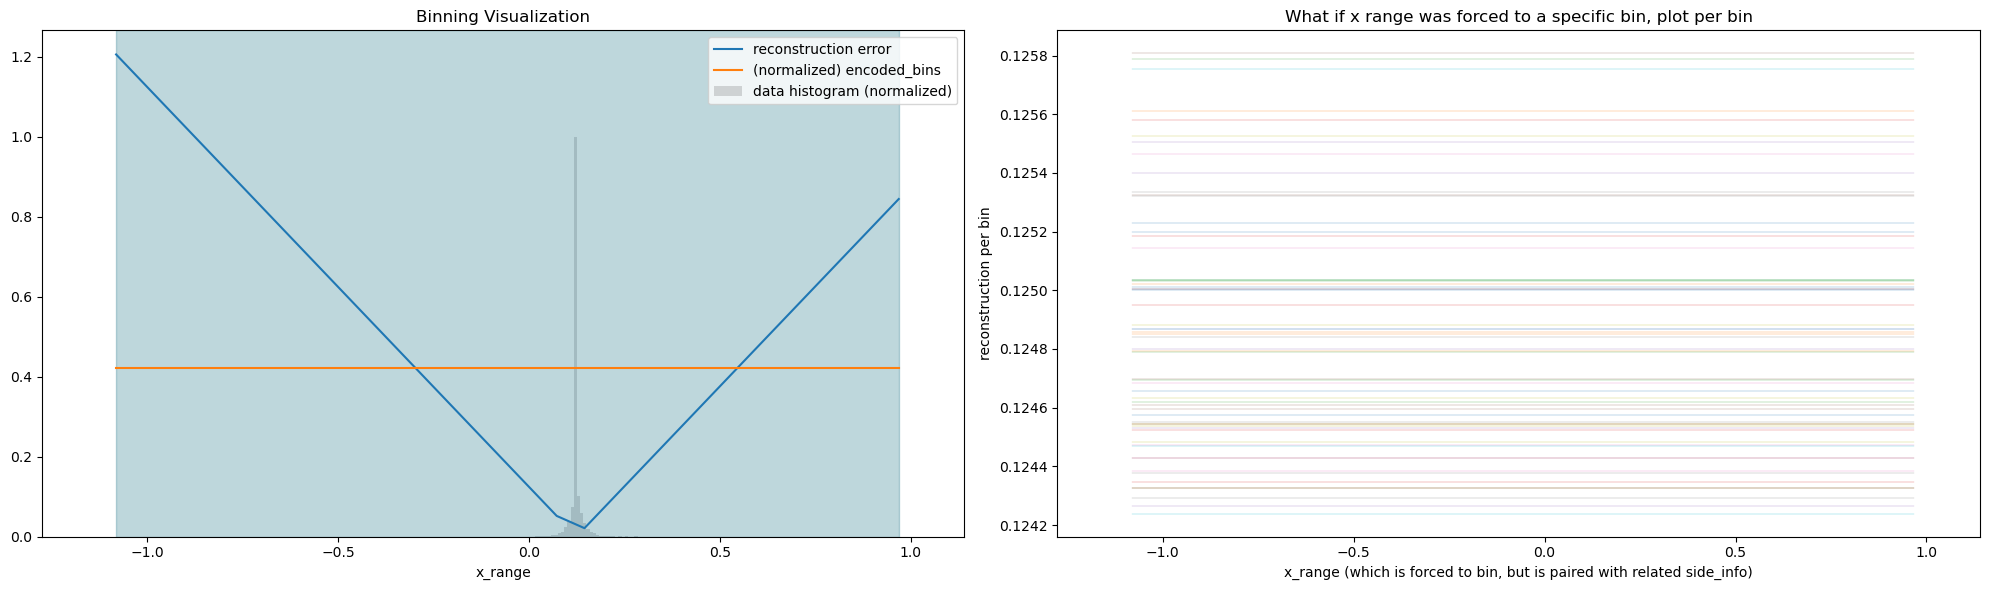

In [55]:
from components.broadcast_components.WZ_models.wz_quant_ANN import plot_bins

plot_bins(wz_quantizer, y[y_argsort], [a[y_argsort] for a in side_info_data], step_count=1000)
plot_bins(wz_quantizer, y[y_argsort], [a[y_argsort] for a in side_info_data], step_count=1000, training_ind=True)